<a href="https://colab.research.google.com/github/abineshabi1027/SKILLINFYTECH/blob/main/SKILLINFYTECHPROJ4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- HR Data Descriptive Statistics ---
              Age  MonthlySalary  YearsAtCompany  JobSatisfaction   Attrition
count  500.000000     500.000000      500.000000       500.000000  500.000000
mean    40.366000    9024.882000        9.696000         2.494000    0.200000
std     10.859092    3453.980285        5.863817         1.119138    0.400401
min     22.000000    3013.000000        0.000000         1.000000    0.000000
25%     30.000000    5861.500000        5.000000         2.000000    0.000000
50%     40.000000    9055.000000       10.000000         2.000000    0.000000
75%     50.000000   11878.500000       15.000000         4.000000    0.000000
max     59.000000   14998.000000       19.000000         4.000000    1.000000

--- Attrition by Job Role ---
             Stayed (%)  Left (%)
JobRole                          
Engineering       81.67     18.33
HR                79.65     20.35
Marketing         80.71     19.29
Sales             77.95     22.05


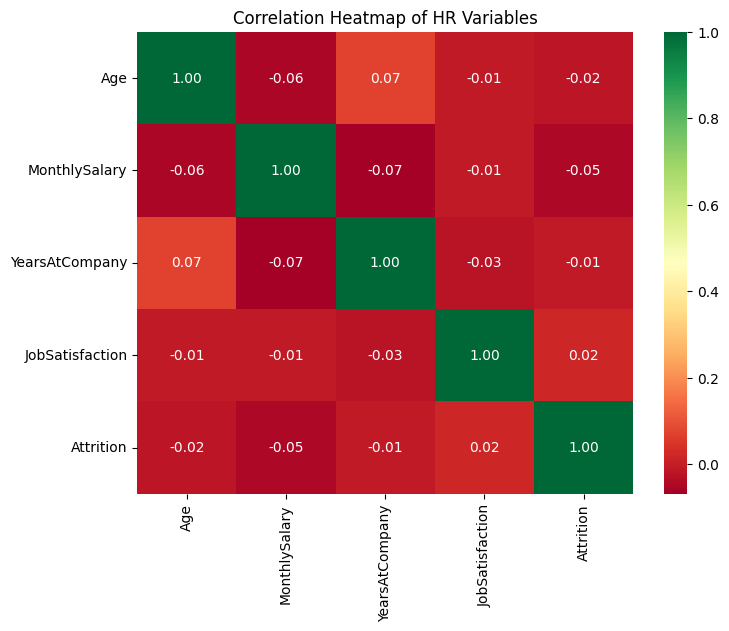

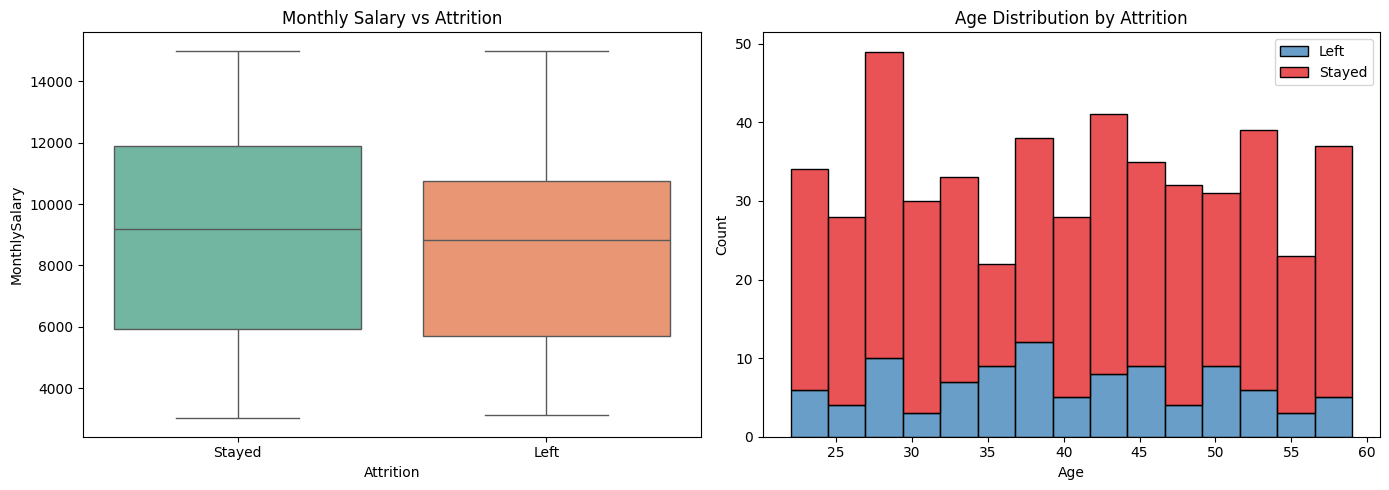

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(101)
n_employees = 500
hr_data = pd.DataFrame({
    'Age': np.random.randint(22, 60, n_employees),
    'MonthlySalary': np.random.randint(3000, 15000, n_employees),
    'YearsAtCompany': np.random.randint(0, 20, n_employees),
    'JobRole': np.random.choice(['Sales', 'Engineering', 'HR', 'Marketing'], n_employees),
    'JobSatisfaction': np.random.randint(1, 5, n_employees),
    'Attrition': np.random.choice([0, 1], n_employees, p=[0.8, 0.2])
})

print("--- HR Data Descriptive Statistics ---")
print(hr_data.describe())

role_attrition = pd.crosstab(hr_data['JobRole'], hr_data['Attrition'], normalize='index') * 100
role_attrition.columns = ['Stayed (%)', 'Left (%)']
print("\n--- Attrition by Job Role ---")
print(role_attrition.round(2))

numeric_hr = hr_data.select_dtypes(include=[np.number])
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_hr.corr(), annot=True, cmap='RdYlGn', fmt=".2f")
plt.title('Correlation Heatmap of HR Variables')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='Attrition', y='MonthlySalary', hue='Attrition', data=hr_data, ax=axes[0], palette='Set2', legend=False)
axes[0].set_title('Monthly Salary vs Attrition')
axes[0].set_xticks(axes[0].get_xticks())
axes[0].set_xticklabels(['Stayed', 'Left'])

sns.histplot(data=hr_data, x='Age', hue='Attrition', multiple='stack', bins=15, ax=axes[1], palette='Set1')
axes[1].set_title('Age Distribution by Attrition')
axes[1].legend(['Left', 'Stayed'])

plt.tight_layout()
plt.show()